# Global E-Commerce Sales Dashboard Project

---
### Overview

The Global E-Commerce Sales Dashboard is a data analytics project designed to help users understand e-commerce sales performance across different countries and regions around the world.

The project provides valuable insights that can support business decision-making by analyzing sales performance, customer behavior, product trends, profitability, and regional performance. Through data analysis and visualization, users can better understand key business metrics and identify important patterns within the data.

The dashboard was developed using Python, Dash, and Plotly. It includes interactive charts, maps, and filters that allow users to explore sales data in a simple and effective way. These interactive features make it easier to identify trends, compare performance, and gain meaningful business insights.

Overall, the Global E-Commerce Sales Dashboard serves as a powerful tool for understanding e-commerce sales and provides a comprehensive view of how e-commerce businesses are performing across different markets.

### Objectives

- How do sales and profit trends vary across regions and product categories?
- Which customer segment is the most profitable?
- How do shipping costs affect profit margins across geographies?
- Which payment methods are preferred in different regions?
- Do customer segments display any preferences for any specific product categories?

---

## 1. Installing and Importing Required Libraries

The first step was to prepare the Python environment by installing the dashboard-related packages and importing the libraries needed for analysis and visualization. Pandas and NumPy were used for data handling, Matplotlib and Seaborn were used for static visualizations, and Plotly/Dash were used to build the interactive dashboard.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
from jupyter_dash import JupyterDash
import warnings
warnings.filterwarnings("ignore")
import plotly.graph_objects as go
from dash.exceptions import PreventUpdate
from matplotlib.colors import to_hex

## 2. Loading the Dataset

The dataset was loaded from the `global_ecommerce_sales.csv` file into a Pandas DataFrame. Loading the data into a DataFrame makes it easier to inspect, clean, transform, summarize, and visualize the information using Python.

In [2]:
df=pd.read_csv("global_ecommerce_sales.csv")
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


## 3. Initial Data Inspection

After loading the dataset, the structure of the data was reviewed using `df.info()`. This helped identify the number of rows and columns, the data types of each field, and whether any columns had missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


## 4. Checking for Missing Values

The next step was to check for null or missing values in each column. This is important because missing data can affect calculations, summaries, charts, and dashboard accuracy.

In [4]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

## 5. Data Type Conversion

The `Order_Date` column was converted into a proper datetime format. This conversion was necessary because date-based analysis, such as extracting year and month, requires the column to be recognized as a date instead of plain text.

In [5]:
df["Order_Date"]= pd.to_datetime(df["Order_Date"])
df.dtypes

Order_ID                    object
Order_Date          datetime64[ns]
Customer_Name               object
Customer_Segment            object
Country                     object
Region                      object
Product_Category            object
Product_Name                object
Quantity                     int64
Unit_Price                 float64
Discount_Percent             int64
Total_Sales                float64
Shipping_Cost              float64
Profit                     float64
Payment_Method              object
dtype: object

## 6. Checking for Duplicate Records

Duplicate records were checked to make sure the dataset did not contain repeated rows. Removing or identifying duplicates helps maintain accurate totals for sales, orders, quantity, and profit.

In [6]:
df.duplicated().sum()

np.int64(0)

## 7. Feature Engineering

New columns were created to support deeper analysis:

- `Year` was extracted from `Order_Date` for year-based filtering.
- `Month` was extracted from `Order_Date` for monthly trend analysis.
- `Quarter` was created from `Order_Date` for quarterly trend analysis
- `Profit_Margin` was calculated using Profit divided by Total Sales, then multiplied by 100.

These new fields made it possible to build time-based charts, KPI cards, and profitability insights in the dashboard.

In [7]:
df['Year']= df['Order_Date'].dt.year.astype(str)
df['Month']= df['Order_Date'].dt.strftime('%b')
df['Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str)
df['Quarter_Label'] = 'Q' + df['Order_Date'].dt.quarter.astype(str)
df['Profit_Margin']= (df['Profit']/df['Total_Sales']* 100).round(2)

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

In [8]:
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method,Year,Month,Quarter,Quarter_Label,Profit_Margin
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery,2023,Jan,2023Q1,Q1,41.88
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery,2023,Jan,2023Q1,Q1,26.68
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card,2023,Jan,2023Q1,Q1,17.18
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal,2023,Jan,2023Q1,Q1,25.03
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card,2023,Jan,2023Q1,Q1,23.95


## 8. Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the overall structure and patterns in the dataset before creating the dashboard. This step included reviewing summary statistics, checking categorical distributions, grouping sales and profit by category and region, and examining trends over time.

### 8.1 Summary Statistics

Descriptive statistics were generated for the numerical columns. This helped summarize the average, minimum, maximum, and spread of key numeric fields such as sales, profit, quantity, and shipping cost.

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,2000,2024-07-12 03:17:16.800000,2023-01-02 00:00:00,2023-10-08 00:00:00,2024-07-12 12:00:00,2025-04-20 06:00:00,2025-12-31 00:00:00,NaN
Quantity,2000.0,3.5575,1.0,2.0,3.0,5.0,15.0,2.704506
Unit_Price,2000.0,73.32949,3.03,18.7575,46.42,90.25,472.56,79.311014
Discount_Percent,2000.0,8.5725,0.0,0.0,10.0,15.0,30.0,7.261274
Total_Sales,2000.0,242.27967,2.42,41.2275,113.125,266.5525,3813.98,382.583802
Shipping_Cost,2000.0,12.90212,5.52,9.4575,11.845,14.92,40.44,5.22319
Profit,2000.0,79.43616,-11.28,6.865,32.83,90.2975,1373.63,137.573593
Profit_Margin,2000.0,20.015265,-417.36,15.3225,28.285,35.13,48.36,27.939326


### 8.2 Categorical Column Distribution

The distribution of important categorical columns was reviewed, including customer segment, product category, region, and payment method. This helped identify the most common groups in the dataset and understand how transactions are distributed across different business dimensions.

In [10]:
cat_columns = ["Customer_Segment","Product_Category","Region","Payment_Method"]
for col in cat_columns:
  counts=df[col].value_counts()
  percentages = df[col].value_counts(normalize=True) * 100
  summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages.round(2)
    })  
  print(f'\n Distribution of {col}')
  print(summary)
  print("\n" + "-"*50 + "\n")



 Distribution of Customer_Segment
                  Count  Percentage (%)
Customer_Segment                       
Consumer           1006           50.30
Corporate           623           31.15
Home Office         371           18.55

--------------------------------------------------


 Distribution of Product_Category
                        Count  Percentage (%)
Product_Category                             
Technology                567           28.35
Office Supplies           513           25.65
Furniture                 507           25.35
Clothing & Accessories    413           20.65

--------------------------------------------------


 Distribution of Region
                      Count  Percentage (%)
Region                                     
North America           578           28.90
Asia Pacific            520           26.00
Europe                  503           25.15
Middle East & Africa    208           10.40
South America           191            9.55

--------------

### 8.3 Sales Analysis by Product Category

Sales were grouped by product category to calculate summary values such as sum, mean, minimum, and maximum sales. This helped compare how different product categories performed in terms of sales.

In [11]:
Sales_per_Category = df.groupby("Product_Category")["Total_Sales"].agg(['sum','mean','min','max'])
Sales_per_Category

,sum,mean,min,max
Product_Category,,,,
Clothing & Accessories,69375.63,167.979734,7.95,1472.80
Furniture,256274.68,505.472742,14.69,3813.98
Office Supplies,19390.81,37.798850,2.42,231.56
Technology,139518.22,246.063880,16.95,1928.48


### 8.4 Profit Analysis by Region

Profit was grouped by region to understand which regions generated higher or lower profit. This analysis supports regional performance comparison and helps identify stronger and weaker markets.

In [12]:
Profit_By_Region = df.groupby('Region')["Profit"].agg(['sum','mean','min','max'])
Profit_By_Region

,sum,mean,min,max
Region,,,,
Asia Pacific,39116.61,75.224250,-10.10,1370.08
Europe,45672.16,90.799523,-6.70,1373.63
Middle East & Africa,14152.48,68.040769,-10.48,564.46
North America,45250.09,78.287353,-8.60,1189.79
South America,14680.98,76.863770,-11.28,844.98


### 8.5 Sales Analysis by Region

Total sales were also grouped by region to compare sales performance across different geographic areas. This provides a broader view of where the business is generating the most revenue.

In [13]:
Sales_By_Region = df.groupby('Region')["Total_Sales"].agg(['sum','mean','min','max'])
Sales_By_Region

,sum,mean,min,max
Region,,,,
Asia Pacific,121707.51,234.052904,2.42,3813.98
Europe,137006.20,272.378131,3.42,3783.56
Middle East & Africa,45918.12,220.760192,4.14,1734.21
North America,133876.38,231.620035,2.58,3007.62
South America,46051.13,241.105393,4.30,2616.41


### 8.6 Sales Analysis by Customer Segment

Sales were grouped by customer segment to understand which customer groups contributed most to overall revenue. This helps compare the value of different customer segments.

In [14]:
Quantity_by_customer = df.groupby("Customer_Segment")["Total_Sales"].agg(['sum','mean','min','max'])
Quantity_by_customer

,sum,mean,min,max
Customer_Segment,,,,
Consumer,256287.74,254.759185,5.86,3783.56
Corporate,146050.39,234.430803,2.42,3813.98
Home Office,82221.21,221.620512,4.30,2701.31


### 8.7 Monthly Sales Trend over Year

Monthly average sales were calculated to identify sales patterns across the year. This step helped prepare the data for the monthly trend chart used later in the dashboard.

In [15]:
Monthly_trends = df.groupby(['Year','Month'])["Total_Sales"].mean()
Monthly_trends

Year  Month
2023  Jan      239.897872
      Feb      325.839808
      Mar      314.832353
      Apr      253.854167
      May      205.461750
      Jun      274.434068
      Jul      265.554746
      Aug      187.986522
      Sep      206.719310
      Oct      282.453968
      Nov      184.249783
      Dec      213.774872
2024  Jan      166.983542
      Feb      332.766667
      Mar      239.775227
      Apr      229.633235
      May      263.400000
      Jun      214.435227
      Jul      298.750600
      Aug      186.487358
      Sep      160.606333
      Oct      229.290132
      Nov      282.987414
      Dec      299.272245
2025  Jan      286.539070
      Feb      183.432000
      Mar      161.923542
      Apr      248.539394
      May      248.194366
      Jun      282.313906
      Jul      246.982951
      Aug      282.552750
      Sep      239.599167
      Oct      240.526515
      Nov      254.845172
      Dec      219.392031
Name: Total_Sales, dtype: float64

## 9. Data Visualization

Several visualizations were created to explore patterns in the data before building the final dashboard. These charts helped show trends, comparisons, distributions, and relationships between important business metrics.

### 9.1 Total Sales by Month

A line chart was created to show how total sales changed across months. This visualization helps identify seasonal sales patterns or months with stronger performance.

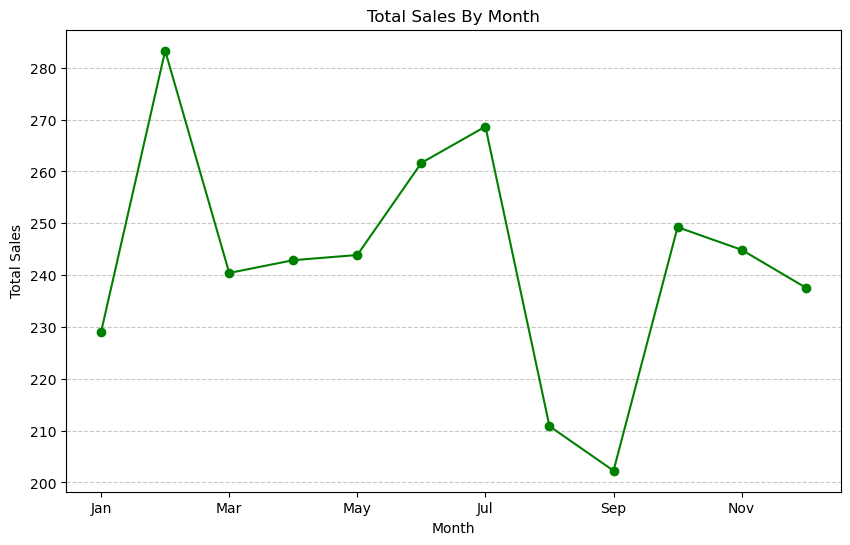

In [16]:
plt.figure(figsize=(10,6))
df.groupby('Month')['Total_Sales'].mean().plot(kind='line', color='green', marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total Sales By Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 9.2 Profit by Quarter

A line chart was created to compare profit across quarters. This helps show whether profit increased, decreased, or stayed consistent over time.

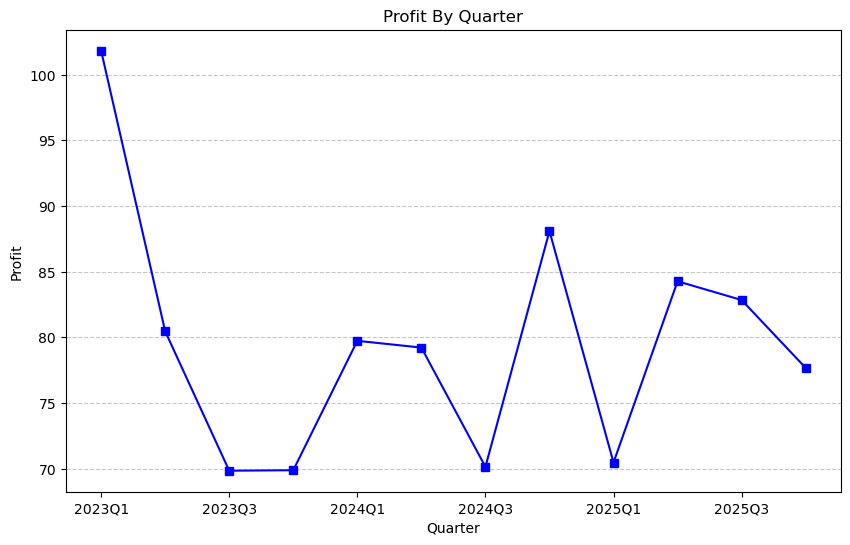

In [17]:
plt.figure(figsize=(10,6))
df.groupby('Quarter')['Profit'].mean().plot(kind='line', color='blue', marker='s')
plt.xlabel('Quarter')
plt.ylabel('Profit')
plt.title('Profit By Quarter')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 9.3 Total Sales by Product Category

A bar chart was used to compare total sales across product categories. Sorting the chart makes it easier to identify the highest-performing categories.

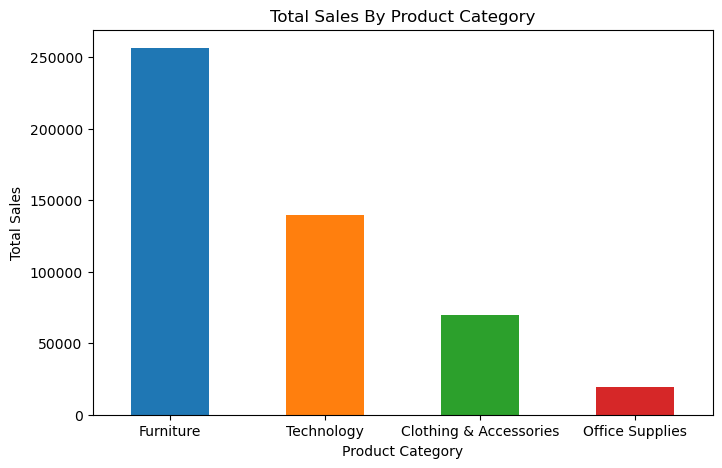

In [18]:
plt.figure(figsize=(8,5))

df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending = False).plot(kind="bar", color=plt.get_cmap('tab10').colors)

plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.title("Total Sales By Product Category")
plt.xticks(rotation=0)
plt.show()

### 9.4 Profit by Product Category

A bar chart was used to compare profit across product categories. This helps determine whether the categories with high sales also generate strong profit.

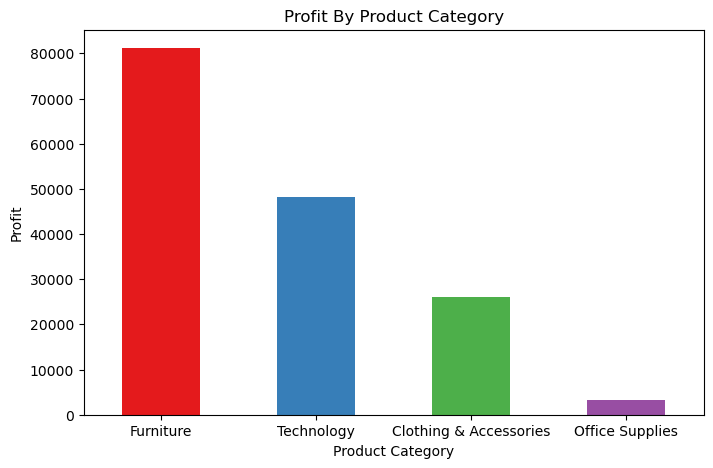

In [19]:
plt.figure(figsize=(8,5))

df.groupby("Product_Category")["Profit"].sum().sort_values(ascending = False).plot(kind="bar", color=plt.get_cmap('Set1').colors)

plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.title("Profit By Product Category")
plt.xticks(rotation=0)
plt.show()

### 9.5 Total Sales by Region

A regional bar chart was created to compare total sales by region. This supports analysis of geographic performance and regional sales differences.

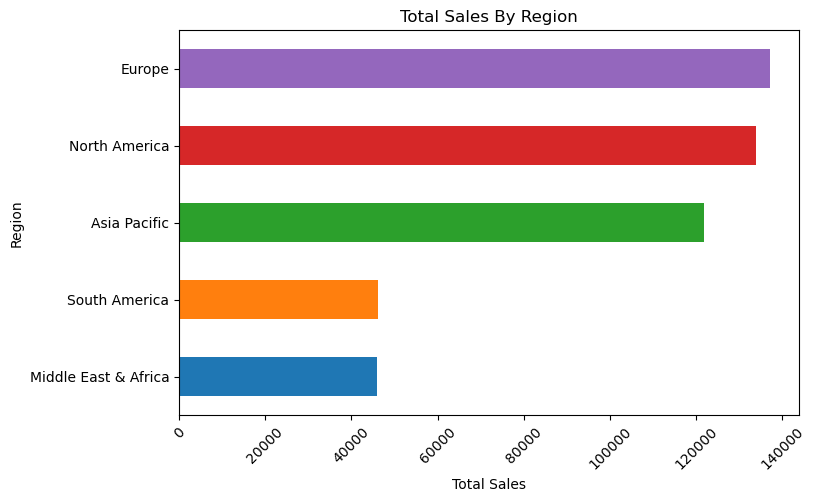

In [20]:
plt.figure(figsize=(8,5))

df.groupby("Region")["Total_Sales"].sum().sort_values(ascending = True).plot(kind="barh", color=plt.get_cmap('tab10').colors)

plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.title("Total Sales By Region")
plt.xticks(rotation=45)
plt.show()

### 9.6 Customer Segment Distribution

A pie chart was used to show the percentage distribution of customer segments. This helps explain which customer groups make up the largest share of the dataset.

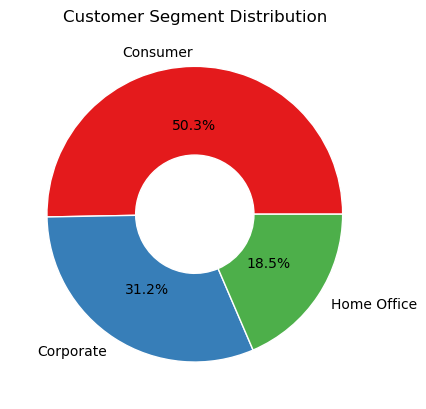

In [21]:
plt.pie(df["Customer_Segment"].value_counts(),labels=df["Customer_Segment"].value_counts().index,autopct='%1.1f%%', 
        colors=plt.get_cmap('Set1').colors, wedgeprops={'width': 0.6, 'edgecolor': 'white'})
plt.title("Customer Segment Distribution")
plt.show()

### 9.7 Payment Method Distribution

A pie chart was created to show how orders are distributed across different payment methods. This helps identify which payment methods are most commonly used by customers.

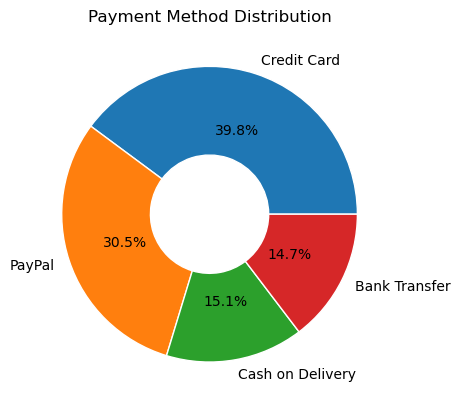

In [22]:
plt.pie(df["Payment_Method"].value_counts(),labels=df["Payment_Method"].value_counts().index,autopct='%1.1f%%',
       wedgeprops={'width': 0.6, 'edgecolor': 'white'})
plt.title("Payment Method Distribution")
plt.show()

### 9.8. Top 15 Products by frequency
A bar chart was used to display the top 15 ordered products. This helps in understanding the customer behavior

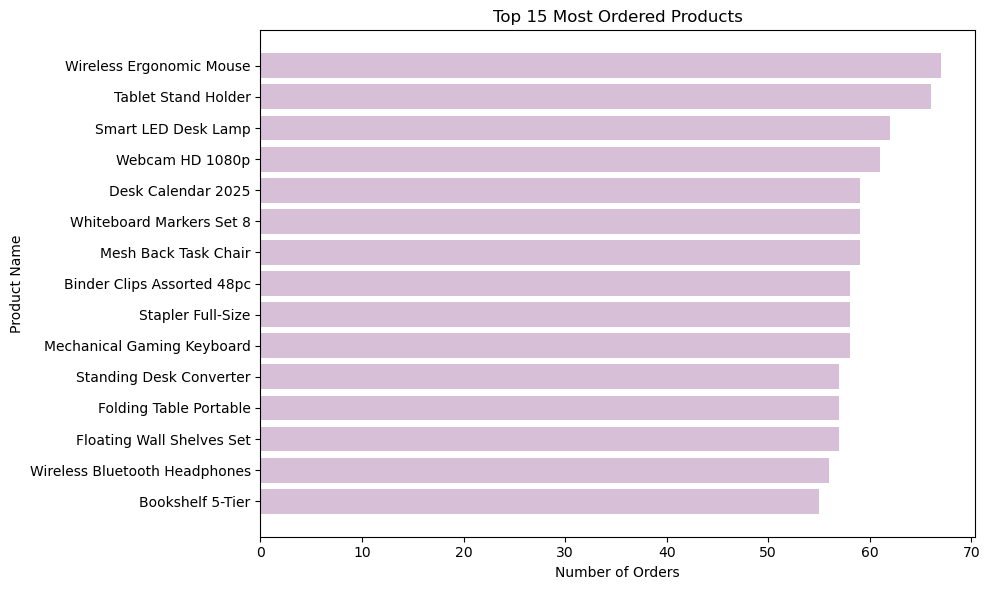

In [23]:
top_product = df['Product_Name'].value_counts().head(15).reset_index();
top_product.columns = ['Product_Name', 'Count']

plt.figure(figsize=(10, 6))
plt.barh(y='Product_Name', width='Count', data=top_product, color='thistle')
plt.title('Top 15 Most Ordered Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
           

### 9.9. Total Sales by Country
A bar chart was used to compare total sales by country. Sorting the chart makes it easier to identify the highest-performing country

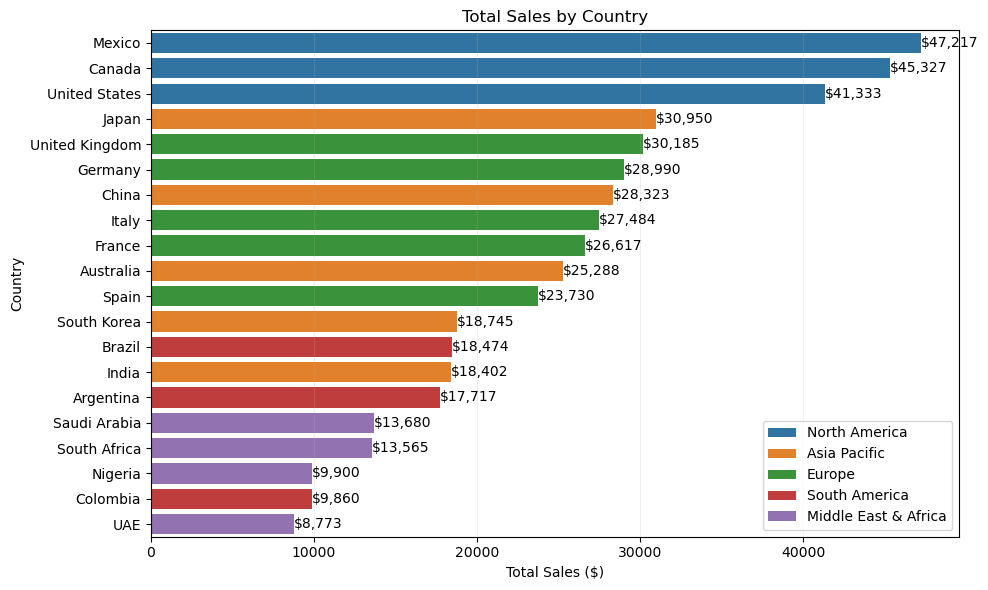

In [24]:
country_summary = df.groupby(['Country', 'Region'])['Total_Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Total_Sales', y='Country', hue='Region', errorbar=None, data=country_summary)
plt.title('Total Sales by Country')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')
plt.legend(loc='lower right')
[ax.bar_label(c, fmt='${:,.0f}', label_type='edge') for c in ax.containers]
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

### 9.10. Correlation Heatmap
A heatmap was used to display the Pearson correlation between numeric features. By using this chart we can analyze the relationship between different features.

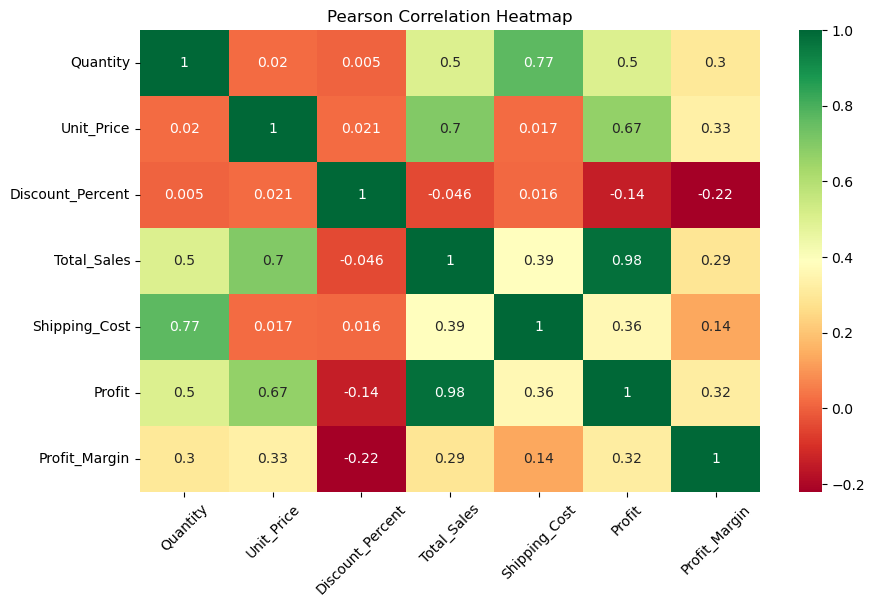

In [25]:
corr_cols = ['Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Profit_Margin']
corr_matrix = df[corr_cols].corr().round(3)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn')
plt.title('Pearson Correlation Heatmap')
plt.xticks(rotation=45)
plt.show()

### 9.11. Relationship Between Shipping Cost and Profit
A scatter plot was created to examine the relationship between shipping cost and profit, with region used as bubbles. This helps explore whether higher shipping costs are associated with lower or higher profit.

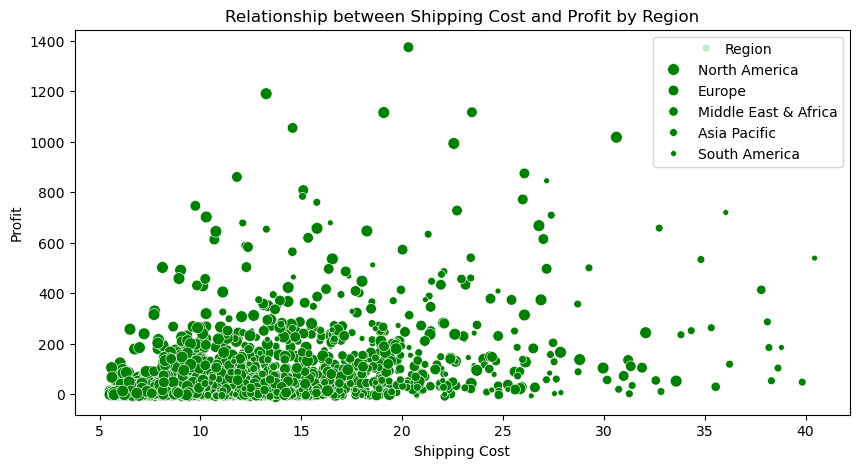

In [26]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Shipping_Cost', y= "Profit", size='Region', color='green', data = df)
plt.xlabel("Shipping Cost")
plt.ylabel("Profit")
plt.title("Relationship between Shipping Cost and Profit by Region")
plt.show()

### 9.12. Relationship Between Total Sales and Profit
A scatter plot was created to examine the relationship between total sales and profit, with quantity used as bubbles. This helps explore whether higher total sales are related with lower or higher profit

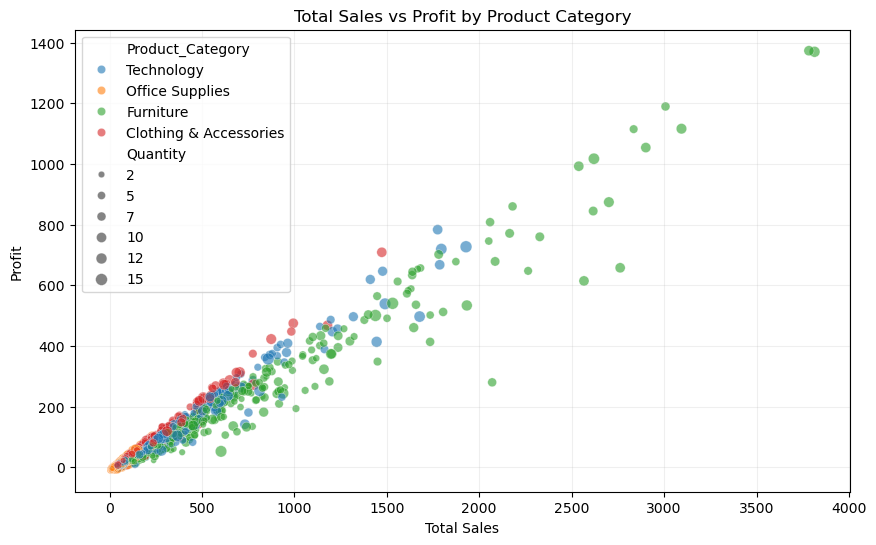

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Sales', y='Profit', data=df, hue='Product_Category', size='Quantity', alpha=0.6)
plt.title('Total Sales vs Profit by Product Category')
plt.xlabel('Total Sales')
plt.ylabel('Profit')
plt.grid(alpha=0.2)
plt.show()

### 9.13. Average Shipping cost by Region
A bar chart was used to compare different regions based on their average shipping cost. By analyzing this chart we could be able to know which region has the highest or lowest shipping cost

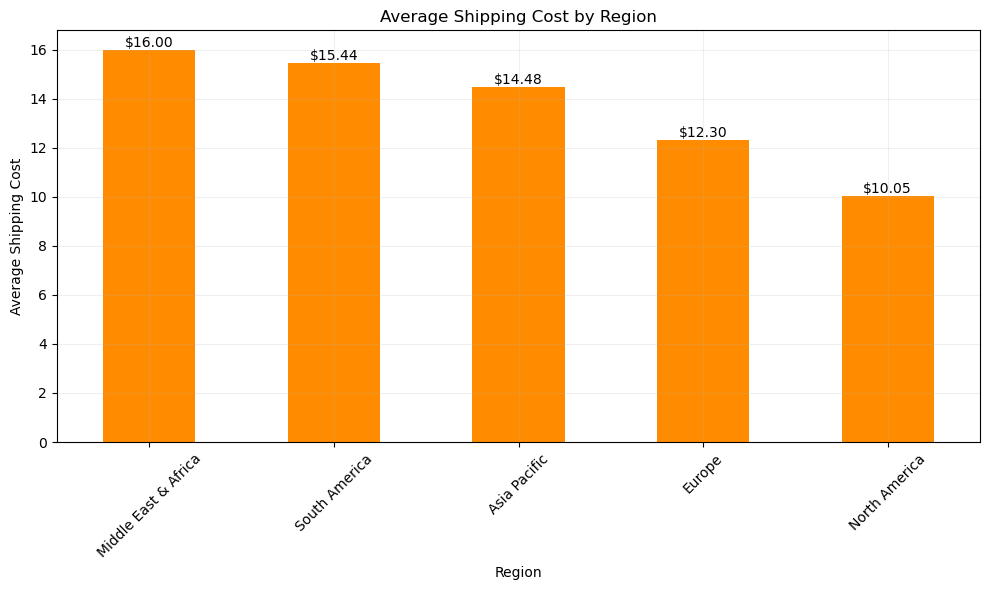

In [28]:
plt.figure(figsize=(10, 6))
ax=df.groupby('Region')['Shipping_Cost'].mean().sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('Average Shipping Cost by Region')
plt.xlabel('Region')
plt.ylabel('Average Shipping Cost')
ax.bar_label(ax.containers[0], fmt='${:.2f}', label_type='edge')
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 9.14. Customer Segment Analysis
A grouped bar chart was used to compare customer segment based on total sales and profit. This helps in exploring which segment has highest or lowest sales as well as highest and lowest profitability

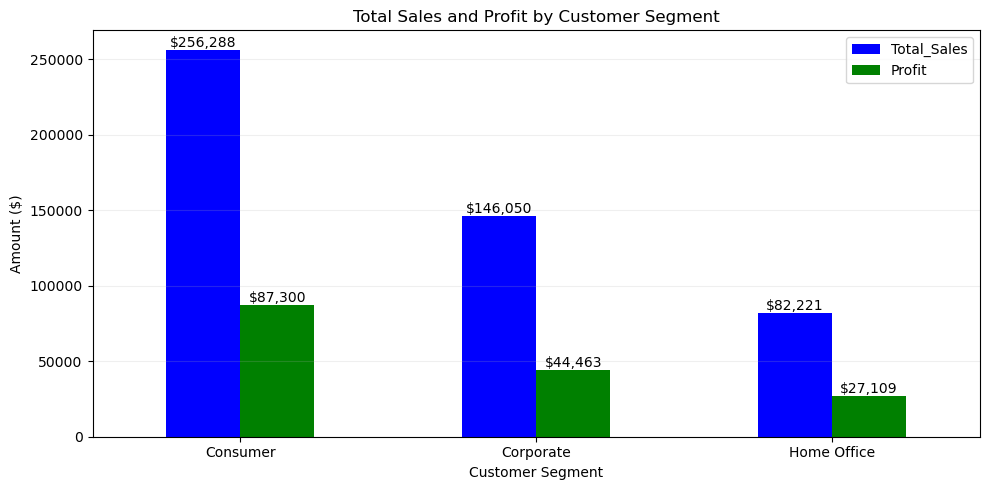

In [29]:
# Segment Comparison
ax = df.groupby('Customer_Segment')[['Total_Sales', 'Profit']].sum().plot(
    kind='bar', 
    color=['blue', 'green'],
    figsize=(10, 5)
)

plt.xlabel("Customer Segment")
plt.ylabel("Amount ($)")
plt.title("Total Sales and Profit by Customer Segment")
ax.bar_label(ax.containers[0], fmt='${:,.0f}', label_type='edge')
ax.bar_label(ax.containers[1], fmt='${:,.0f}', label_type='edge')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 9.15. Customer Segment and Product Category cross-analysis
A grouped bar chart was used to perform a cross-analysis between customer segment and product category based on total sales. It helps in understanding the distribution of product category within customer segment

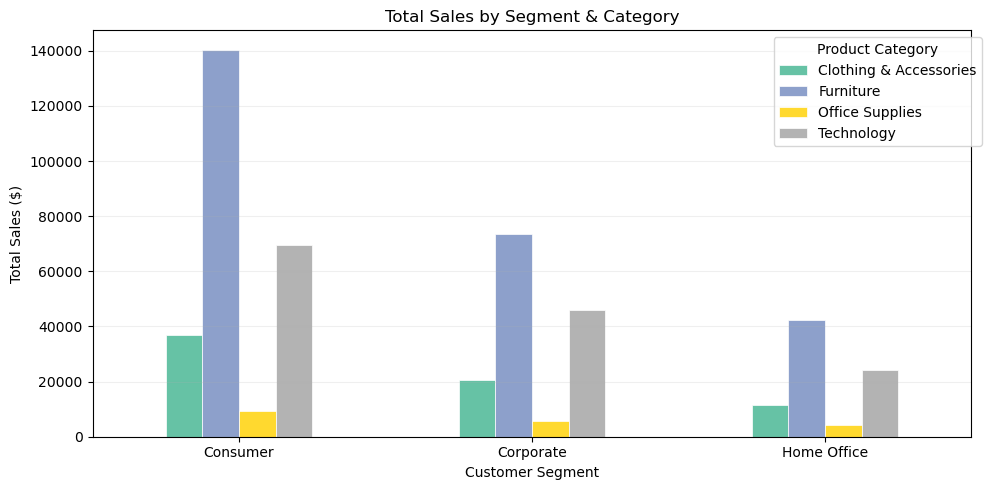

In [30]:
seg_cat = df.groupby(['Customer_Segment', 'Product_Category'])['Total_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
seg_cat.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Total Sales by Segment & Category')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Customer Segment')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Product Category', bbox_to_anchor=(1.02, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 9.16. Total Sales and Profit by Product Category
A grouped bar chart was used to compare product category based on total sales and profit. This helps in exploring which category has highest or lowest sales as well as highest and lowest profitability

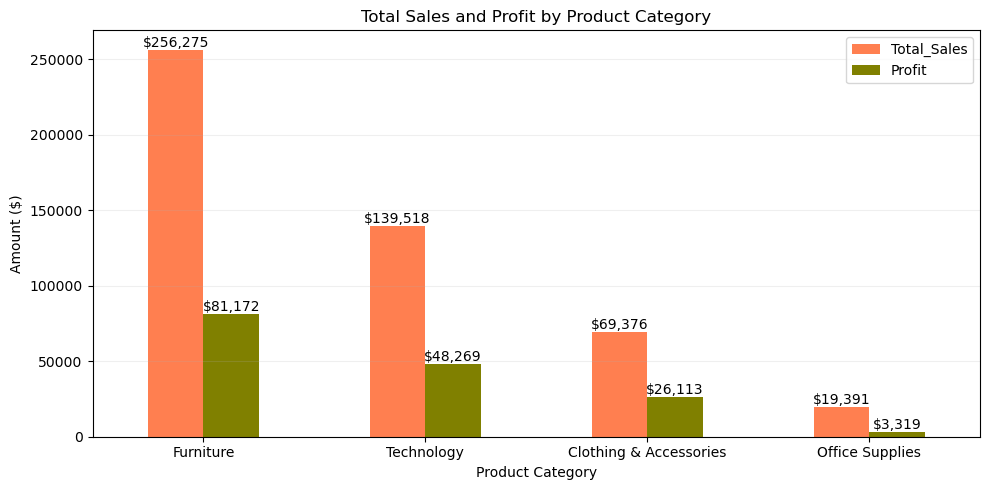

In [31]:
ax = df.groupby('Product_Category')[['Total_Sales', 'Profit']].sum().sort_values('Total_Sales', ascending=False).plot(
    kind='bar', 
    color=['coral', 'olive'],
    figsize=(10, 5)
)

plt.xlabel("Product Category")
plt.ylabel("Amount ($)")
plt.title("Total Sales and Profit by Product Category")
ax.bar_label(ax.containers[0], fmt='${:,.0f}', label_type='edge')
ax.bar_label(ax.containers[1], fmt='${:,.0f}', label_type='edge')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### 10. Interactive Dashboard Development
After completing the exploratory analysis and visualizations, an interactive dashboard was created using Dash and Plotly. The dashboard allows users to filter the data by year and view updated KPI cards and charts.

The dashboard includes the following components:

- Year, regions, quarters dropdown filters for interactive filtering
- KPI cards for total sales, total profit, profit margin, total orders, units sold, and shipping cost
- A bar chart showing total sales and profit by product category
- A line chart showing average monthly sales
- A donut chart showing total sales by payment method
- A horizontal bar chart showing profit by country
- A geographical map showing toatal sales by country

The callback function updates all dashboard visuals based on the selected year values. This makes the dashboard interactive and allows users to explore changes in sales and profit performance over time.

In [34]:
# ----------------------------
# Create Dash app
# ----------------------------
app = dash.Dash(__name__)
app.title = "Sales Dashboard"

# ----------------------------
# Styles
# ----------------------------
kpi_card_style = {
    'backgroundColor': '#ffffff',
    'borderRadius': '14px',
    'boxShadow': '0 4px 12px rgba(0,0,0,0.08)',
    'padding': '10px 12px',
    'textAlign': 'center',
    'width': '160px',
    'height': '85px',
    'display': 'flex',
    'flexDirection': 'column',
    'justifyContent': 'center',
    'alignItems': 'center',
    'border': '1px solid #f0f0f0',
    'flexShrink': '0'
}

kpi_title_style = {
    'fontSize': '15px',
    'fontWeight': '500',
    'margin': '0 0 6px 0',
    'color': '#555',
    'whiteSpace': 'nowrap'
}

kpi_value_style = {
    'fontSize': '22px',
    'fontWeight': '700',
    'margin': '0',
    'lineHeight': '1.1'
}

chart_card_style = {
    'backgroundColor': '#ffffff',
    'borderRadius': '12px',
    'boxShadow': '0 4px 12px rgba(0,0,0,0.10)',
    'padding': '6px',
    'flex':'1',
    'minHeight': '200px',
    'border': '1px solid #eeeeee'
}

full_chart_card_style = {
    'backgroundColor': '#ffffff',
    'borderRadius': '10px',
    'boxShadow': '0 4px 12px rgba(0,0,0,0.10)',
    'padding': '10px',
    'border': '1px solid #eeeeee',
    'marginBottom': '20px'
}

dropdown_style = {
    'width': '28%'
}

# ----------------------------
# Layout
# ----------------------------
app.layout = html.Div([

    html.H2(
        "🌍 Global E-Commerce Sales Dashboard",
        style={
            'textAlign': 'center',
            'color': '#2C3E50',
            'fontSize':'40px',
            'fontWeight': '600',
            'marginBottom': '20px'
        }
    ),

    # ----------------------------
    # Filters Row
    # ----------------------------
    html.Div([

        dcc.Dropdown(
            id='year-filter',
            options=[
                {"label": y, "value": y}
                for y in sorted(df['Year'].unique())
            ],
            value=list(sorted(df['Year'].unique())),
            multi=True,
            clearable=True,
            placeholder="Select Year(s)",
            style=dropdown_style
        ),

        dcc.Dropdown(
            id='region-filter',
            options=[
                {"label": r, "value": r}
                for r in sorted(df['Region'].unique())
            ],
            value=list(sorted(df['Region'].unique())),
            multi=True,
            clearable=True,
            placeholder="Select Region(s)",
            style=dropdown_style
        ),

        dcc.Dropdown(
            id='quarter-filter',
            options=[
                {"label": q, "value": q}
                for q in ['Q1', 'Q2', 'Q3', 'Q4']
            ],
            value=['Q1', 'Q2', 'Q3', 'Q4'],
            multi=True,
            clearable=True,
            placeholder="Select Quarter(s)",
            style=dropdown_style
        ),

        html.Button(
            "Reset",
            id="reset-button",
            n_clicks=0,
            style={
                'height': '38px',
                'backgroundColor': '#2E86C1',
                'color': 'white',
                'border': 'none',
                'borderRadius': '6px',
                'padding': '0 16px',
                'cursor': 'pointer',
                'fontWeight': 'bold'
            }
        )

    ], style={
        'display': 'flex',
        'gap': '15px',
        'marginTop': '20px',
        'marginBottom': '20px',
        'alignItems': 'center'
    }),

    # ----------------------------
    # KPI Cards
    # ----------------------------
    html.Div([

        html.Div([
            html.P("💰 Total Sales", style=kpi_title_style),
            html.H4(id='total-sales', style={**kpi_value_style, 'color': 'green'})
        ], style=kpi_card_style),

        html.Div([
            html.P("📊 Total Profit", style=kpi_title_style),
            html.H4(id='profit', style={**kpi_value_style, 'color': 'blue'})
        ], style=kpi_card_style),

        html.Div([
            html.P("🚚 Shipping Cost", style=kpi_title_style),
            html.H4(id='shipping-cost', style={**kpi_value_style, 'color': 'orange'})
        ], style=kpi_card_style),


        html.Div([
            html.P("💹 Profit Margin", style=kpi_title_style),
            html.H4(id='profit-margin', style={**kpi_value_style, 'color': 'purple'})
        ], style=kpi_card_style),

        
        html.Div([
            html.P("🛍️ Total Orders", style=kpi_title_style),
            html.H4(id='order-count', style={**kpi_value_style, 'color': '#58D68D'})
        ], style=kpi_card_style),

        html.Div([
            html.P("📦 Units Sold", style=kpi_title_style),
            html.H4(id='unit-sold', style={**kpi_value_style, 'color': 'royalblue'})
        ], style=kpi_card_style),

    ], style={
        'display': 'flex',
        'justifyContent': 'flex-start',
        'gap': '14px',
        'marginTop': '25px',
        'marginBottom': '25px',
        'flexWrap': 'nowrap',
        'overflowX': 'auto',
        'padding': '5px 0'
    }),

# ----------------------------
# Row 1 Charts
# ----------------------------
html.Div([

    html.Div([
        dcc.Graph(id='category-sales-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style),

    html.Div([
        dcc.Graph(id='top-products-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style)


], style={
    'display': 'flex',
    'justifyContent': 'space-between',
    'gap': '15px',
    'marginBottom': '20px'
}),

# ----------------------------
# Row 2 Charts
# ----------------------------
html.Div([


    html.Div([
        dcc.Graph(id='segment-category-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style),
        
    html.Div([
        dcc.Graph(id='monthly-sales-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style)


], style={
    'display': 'flex',
    'justifyContent': 'space-between',
    'gap': '15px',
    'marginBottom': '20px'
}),

# ----------------------------
# Row 3 Charts
# ----------------------------
html.Div([

     html.Div([
        dcc.Graph(id='payment-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style),

     html.Div([
        dcc.Graph(id='sales-profit-category-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style)
         
], style={
    'display': 'flex',
    'justifyContent': 'space-between',
    'gap': '15px',
    'marginBottom': '20px'
}),

# ----------------------------
# Row 4 Charts
# ----------------------------
html.Div([
    
    html.Div([
        dcc.Graph(id='country-profit-chart', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style),

    html.Div([
        dcc.Graph(id='sales-map', style={'height': '380px', 'width':'100%'})
    ], style=chart_card_style)

], style={
    'display': 'flex',
    'justifyContent': 'space-between',
    'gap': '15px',
    'marginBottom': '20px'
}),
    
], style={
    'padding': '20px',
    'fontFamily': 'Arial',
    'background': 'linear-gradient(135deg, #EAF4FF 15%, #F7ECFF 35%, #EFFFF5 70%, #FFF7E6 100%)',
    'backgroundAttachment': 'fixed',
    'minHeight': '100vh'
})

# ----------------------------
# Reset Callback
# ----------------------------
@app.callback(
    Output('year-filter', 'value'),
    Output('region-filter', 'value'),
    Output('quarter-filter', 'value'),
    Input('reset-button', 'n_clicks'),
    prevent_initial_call=True
)
def reset_filters(n_clicks):

    if n_clicks == 0:
        raise PreventUpdate

    # Empty list shows placeholder and removes filter
    return [], [], []

# ----------------------------
# Callback
# ----------------------------
@app.callback(
    Output('total-sales', 'children'),
    Output('profit', 'children'),
    Output('profit-margin', 'children'),
    Output('order-count', 'children'),
    Output('unit-sold', 'children'),
    Output('shipping-cost', 'children'),
    Output('category-sales-chart', 'figure'),
    Output('monthly-sales-chart', 'figure'),
    Output('payment-chart', 'figure'),
    Output('sales-map', 'figure'),
    Output('country-profit-chart', 'figure'),
    Output('segment-category-chart', 'figure'),
    Output('top-products-chart', 'figure'),
    Output('sales-profit-category-chart','figure'),
    Input('year-filter', 'value'),
    Input('region-filter', 'value'),
    Input('quarter-filter', 'value'),
    Input('sales-map', 'clickData')
)
def update_charts(selected_year, selected_region, selected_quarter, clickData):

    filtered = df.copy()

    # ----------------------------
    # Apply Filters
    # ----------------------------
    if selected_year:
        filtered = filtered[filtered['Year'].isin(selected_year)]

    if selected_region:
        filtered = filtered[filtered['Region'].isin(selected_region)]

    if selected_quarter:
        filtered = filtered[filtered['Quarter_Label'].isin(selected_quarter)]

    # ----------------------------
    # Handle Empty Data
    # ----------------------------
    if filtered.empty:

        empty_fig = px.scatter(title="No data available for selected filters")

        empty_fig.update_layout(
            paper_bgcolor='white',
            plot_bgcolor='white',
            title={'x': 0.5}
        )

        return (
            "$0",
            "$0",
            "0.0%",
            "0",
            "0",
            "$0",
            empty_fig,
            empty_fig,
            empty_fig,
            empty_fig,
            empty_fig,
            empty_fig,
            empty_fig,
            empty_fig
        )

    # ----------------------------
    # KPI Values
    # ----------------------------
    total_sales = f"${filtered['Total_Sales'].sum():,.0f}"
    total_profit = f"${filtered['Profit'].sum():,.0f}"
    profit_margin = f"{filtered['Profit_Margin'].mean():.1f}%"
    order_count = f"{filtered['Order_ID'].count():,}"
    unit_sold = f"{filtered['Quantity'].sum():,}"
    shipping_cost = f"${filtered['Shipping_Cost'].sum():,.0f}"

    # ----------------------------------------
    # Chart 1: Total Sales by Product Category
    # ----------------------------------------
    category_sales = (
        filtered.groupby('Product_Category', as_index=False)['Total_Sales']
        .sum()
        .sort_values('Total_Sales', ascending=False)
    )

    tab10_colors = [to_hex(color) for color in plt.get_cmap('tab10').colors]

    fig_category = px.bar(
        category_sales,
        x='Product_Category',
        y='Total_Sales',
        color='Product_Category',
        color_discrete_sequence=tab10_colors,
        title="Total Sales by Product Category",
        text='Total_Sales'
    )

    fig_category.update_traces(
        texttemplate='$%{text:,.0f}',
        textposition='outside',
        cliponaxis=False
    )

    fig_category.update_layout(
        showlegend=False,
        paper_bgcolor='white',
        plot_bgcolor='white',
        yaxis_gridcolor='lightgray',
        xaxis_title="Product Category",
        yaxis_title="Total Sales",
        title={'text':"Total Sales by Product Category",'x': 0.5, 'font':{'size':15}},
        margin=dict(t=80, b=80, l=60, r=40)
    )

    fig_category.update_yaxes(
        range=[0, category_sales['Total_Sales'].max() * 1.2]
    )

    # -------------------------------
    # Chart 2: Average Monthly Sales
    # -------------------------------
    monthly_sales = (
        filtered.groupby('Month', observed=False, as_index=False)['Total_Sales']
        .mean()
        .sort_values('Month')
    )

    fig_monthly = px.line(
        monthly_sales,
        x='Month',
        y='Total_Sales',
        title="Average Monthly Sales",
        markers=True,
        color_discrete_sequence=["green"]
    )

    fig_monthly.update_layout(
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis_showgrid=False,
        yaxis_gridcolor='lightgray',
        xaxis_title="Month",
        yaxis_title="Average Sales",
        title={'text':"Average Monthly Sales",'x': 0.5, 'font':{'size':15}}
    )

    # ------------------------------------
    # Chart 3: Payment Method Distribution
    # ------------------------------------
    payment_summary = (
        filtered.groupby('Payment_Method', as_index=False)['Total_Sales']
        .sum()
    )

    fig_payment = px.pie(
        payment_summary,
        names='Payment_Method',
        values='Total_Sales',
        title="Sales Distribution by Payment Method",
        hole=0.40,
        color_discrete_sequence=[
        '#2E86C1',
        '#58D68D',
        '#F5B041',
        '#AF7AC5',
        '#EC7063'
    ]
)
    fig_payment.update_traces(
    textinfo='percent+label',
    textposition='inside',
    insidetextorientation='radial',
    marker=dict(
        line=dict(color='white', width=2)
    ),
    pull=[0.04 if i == 0 else 0 for i in range(len(payment_summary))]
)

    fig_payment.update_layout(
        paper_bgcolor='white',
        plot_bgcolor='white',
        title={'text':"Sales Distribution by Payment Method",'x': 0.5, 'font':{'size':15}}
    )
    # -------------------------------------------
    # Chart 4: Choropleth Map - Sales by Country
    # -------------------------------------------
    country_sales = (
        filtered.groupby(['Region', 'Country'], as_index=False)
        .agg({
            'Total_Sales': 'sum',
            'Profit': 'sum'
        })
    )

    fig_map = px.choropleth(
        country_sales,
        locations='Country',
        locationmode='country names',
        color='Total_Sales',
        hover_name='Country',
        hover_data={
            'Region': True,
            'Total_Sales': ':,.0f',
            'Profit': ':,.0f',
            'Country': False
        },
        color_continuous_scale=[[0.0, '#3B007A'],[0.25, '#9A0079'],[0.50, '#FF006E'],[0.75, '#FF6B00'],[1.0, '#FFC300']],
        title='Total Sales by Country'
    )

    fig_map.update_layout(
        paper_bgcolor='#ffffff',
        plot_bgcolor='#ffffff',
        title={'text':"Total Sales by Country",'x': 0.5, 'font':{'size':15}},
        margin=dict(t=90, l=20, r=20, b=20),

        coloraxis_colorbar=dict(
        title='Total Sales',
        orientation='h',
        x=0.5,
        xanchor='center',
        y=1.03,
        yanchor='bottom',
        thickness=15,
        len=0.75,
        tickprefix='$'
    ),
        geo=dict(
            showframe=False,
            showcoastlines=True,
            coastlinecolor='#444444',
            showland=True,
            landcolor='#F8FAFC',
            showocean=True,
            oceancolor='#F8FAFC',
            showcountries=True,
            countrycolor='#444444',
            projection_type='natural earth',
            bgcolor='#ffffff'
        )
    )

    # ----------------------------
    # Drill Down: Profit by Selected Country
    # ----------------------------
    if clickData and 'points' in clickData:

        selected_country = clickData['points'][0]['location']

        country_profit = (
            filtered[filtered['Country'] == selected_country]
            .groupby('Product_Category', as_index=False)['Profit']
            .sum()
            .sort_values('Profit', ascending=True)
        )

        fig_country_profit = px.bar(
            country_profit,
            x='Profit',
            y='Product_Category',
            orientation='h',
            color='Product_Category',
            title=f'Profit by Product Category in {selected_country}',
            text='Profit'
        )

    else:

        country_profit = (
            filtered.groupby('Country', as_index=False)['Profit']
            .sum()
            .sort_values('Profit', ascending=False)
            .head(10)
            .sort_values('Profit', ascending=False)
        )

        fig_country_profit = px.bar(
            country_profit,
            x='Profit',
            y='Country',
            orientation='h',
            color='Country',
            title='Top 10 Countries by Profit',
            text='Profit'
        )

    fig_country_profit.update_traces(
        texttemplate='$%{text:,.0f}',
        textposition='outside',
        cliponaxis=False
    )

    fig_country_profit.update_layout(
        showlegend=False,
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis_gridcolor='lightgray',
        xaxis_title='Profit',
        yaxis_title='',
        title={'text': "Top 10 Countries by Profit",'x': 0.5, 'font':{'size':15}},
        margin=dict(t=80, b=60, l=120, r=80)
    )


    # ----------------------------
    # Chart 5: Top 15 Most Ordered Products
    # ----------------------------
    top_products = (
        filtered['Product_Name']
        .value_counts()
        .head(15)
        .reset_index()
    )

    top_products.columns = ['Product_Name', 'Count']

    fig_products = px.bar(
        top_products.sort_values('Count', ascending=True),
        x='Count',
        y='Product_Name',
        orientation='h',
        title="Top 15 Most Ordered Products",
        text='Count'
    )

    fig_products.update_traces(
        texttemplate='%{text:,.0f}',
        textposition='outside',
        cliponaxis=False
    )

    fig_products.update_layout(
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis_gridcolor='lightgray',
        xaxis_title="Number of Orders",
        yaxis_title="Product Name",
        title={'text':"Top 15 Most Ordered Products",'x': 0.5, 'font':{'size':15}},
        margin=dict(t=80, b=60, l=140, r=60)
    )

    fig_products.update_xaxes(
        range=[0, top_products['Count'].max() * 1.2]
    )

    # ------------------------------------------------
    # Chart 6: Total Sales by Segment and Category
    # ------------------------------------------------
    segment_category_sales = (
        filtered.groupby(['Customer_Segment', 'Product_Category'], as_index=False)['Total_Sales']
        .sum()
        .sort_values('Total_Sales', ascending=False)
    )

    fig_segment_category = px.bar(
        segment_category_sales,
        x='Customer_Segment',
        y='Total_Sales',
        color='Product_Category',
        barmode='group',
        title='Total Sales by Segment and Product Category',
        text='Total_Sales'
    )

    fig_segment_category.update_traces(
        texttemplate='$%{text:,.0f}',
        textposition='outside',
        cliponaxis=False
    )

    fig_segment_category.update_layout(
        paper_bgcolor='white',
        plot_bgcolor='white',
        yaxis_gridcolor='lightgray',
        xaxis_title='Customer Segment',
        yaxis_title='Total Sales',
        legend_title='Product Category',
        showlegend=False,
        title={
            'text': 'Total Sales by Segment and Product Category',
            'x': 0.5,
            'font': {'size': 15}
        },
        margin=dict(t=80, b=120, l=60, r=40)
    )

    # ------------------------------------------------
    # Chart 7: Total Sales and Profit by Product Category
    # ------------------------------------------------

    
    sales_profit_category = (
        filtered.groupby('Product_Category', as_index=False)
        .agg({
            'Total_Sales': 'sum',
            'Profit': 'sum'
        })
        .sort_values('Total_Sales', ascending=False)
    )
    sales_profit_melted = sales_profit_category.melt(
        id_vars='Product_Category',
        value_vars=['Total_Sales', 'Profit'],
        var_name='Metric',
        value_name='Amount'
    )

    sales_profit_melted['Product_Category_Wrapped'] = sales_profit_melted['Product_Category'].replace({
    'Clothing & Accessories': 'Clothing &<br>Accessories',
    'Office Supplies': 'Office<br>Supplies'
})
    fig_sales_profit_category = px.bar(
        sales_profit_melted,
        x='Product_Category_Wrapped',
        y='Amount',
        color='Metric',
        barmode='group',
        title='Total Sales and Profit by Product Category',
        text='Amount'
    )

    fig_sales_profit_category.update_traces(
        texttemplate='$%{text:,.0f}',
        textposition='outside',
        cliponaxis=False
    )

    fig_sales_profit_category.update_layout(
        paper_bgcolor='white',
        plot_bgcolor='white',
        yaxis_gridcolor='lightgray',
        xaxis_title='Product Category',
        yaxis_title='Amount',
        legend_title='Metric',
        title={
            'text': 'Total Sales and Profit by Product Category',
            'x': 0.5,
            'font': {'size': 15}
        },
        margin=dict(t=60, b=100, l=40, r=10)
    )
    fig_sales_profit_category.update_xaxes(
    tickangle=0, tickfont=dict(size=11)
)

    return (
        total_sales,
        total_profit,
        profit_margin,
        order_count,
        unit_sold,
        shipping_cost,
        fig_category,
        fig_monthly,
        fig_payment,
        fig_map,
        fig_country_profit,
        fig_segment_category,
        fig_sales_profit_category,
        fig_products
    )

# ----------------------------
# Run app
# ----------------------------
if __name__ == '__main__':
    app.run(debug=True, host='127.0.0.1', port=8050)